# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
import sklearn.utils
sklearn.utils.check_random_state(32)

from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Load Dataset

In [2]:
df = pd.read_csv('Dataset/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
print("Missing value pada tiap fitur:")
print(df.isnull().sum())

Missing value pada tiap fitur:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
print("Jumlah data duplikat: ", df.duplicated().sum())

Jumlah data duplikat:  0


In [8]:
df = df.drop(columns=['Age','Gender', 'CustomerID'])

In [9]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Preprocessing

In [10]:
scaler = StandardScaler()

In [11]:
X = scaler.fit_transform(df)

# Menentukan Jumlah Cluster

Gunakan Kmeans sebagai baseline

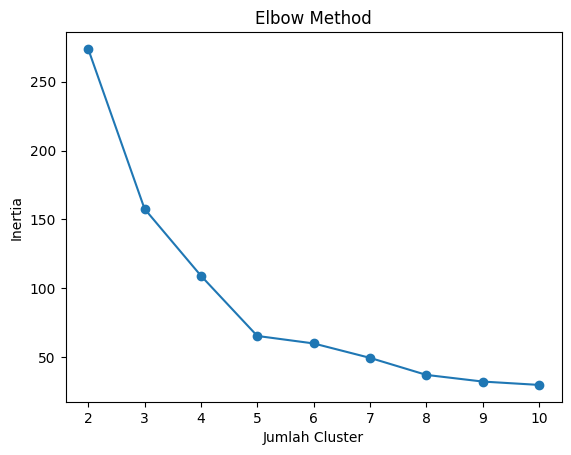

In [12]:
inertia = []

K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 0
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"Cluster {k} = Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nJumlah cluster terbaik: {best_k} dengan Silhouette Score = {best_score:.4f}")

Cluster 2 = Silhouette Score = 0.3973
Cluster 3 = Silhouette Score = 0.4666
Cluster 4 = Silhouette Score = 0.4943
Cluster 5 = Silhouette Score = 0.5547
Cluster 6 = Silhouette Score = 0.5138
Cluster 7 = Silhouette Score = 0.5020
Cluster 8 = Silhouette Score = 0.4550
Cluster 9 = Silhouette Score = 0.4567
Cluster 10 = Silhouette Score = 0.4448

Jumlah cluster terbaik: 5 dengan Silhouette Score = 0.5547


# Modelling

## KMeans

In [14]:
clusterNum = 5
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, random_state=42)
k_means.fit(X)

KMeans(n_clusters=5, random_state=42)

In [15]:
kmeans_predictions = k_means.predict(X)

In [16]:
k_means_labels = k_means.labels_
k_means_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [17]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [18]:
sil_score = silhouette_score(X, kmeans_predictions)
sil_score

np.float64(0.5546571631111091)

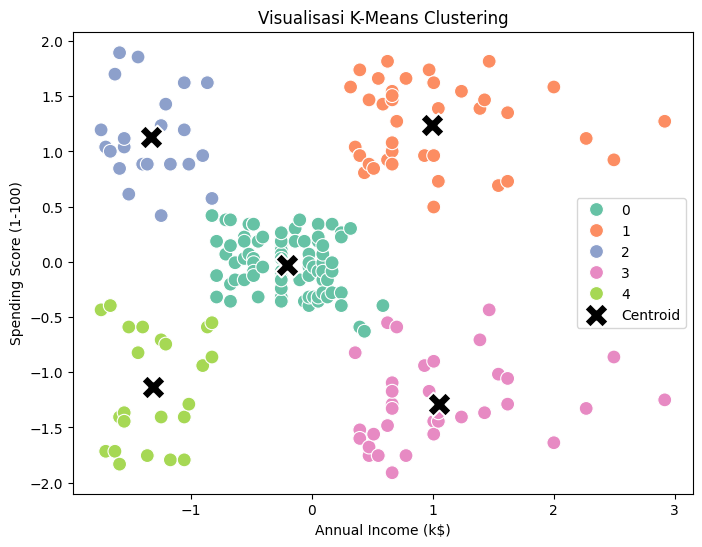

In [19]:
df_plot = pd.DataFrame(X, columns=["Annual Income (k$)", "Spending Score (1-100)"])
df_plot["Cluster"] = kmeans_predictions

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=100
)

centers = pd.DataFrame(k_means_cluster_centers, columns=["Annual Income (k$)", "Spending Score (1-100)"])
sns.scatterplot(
    data=centers,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=300,
    color="black",
    marker="X",
    label="Centroid"
)

plt.title("Visualisasi K-Means Clustering")
plt.legend()
plt.show()

## Hierarchical Clustering

In [20]:
Z = hierarchy.linkage(X, 'complete')

In [21]:
max_d = 3
clusters = fcluster(Z, max_d, criterion='distance')
clusters

array([2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4], dtype=int32)

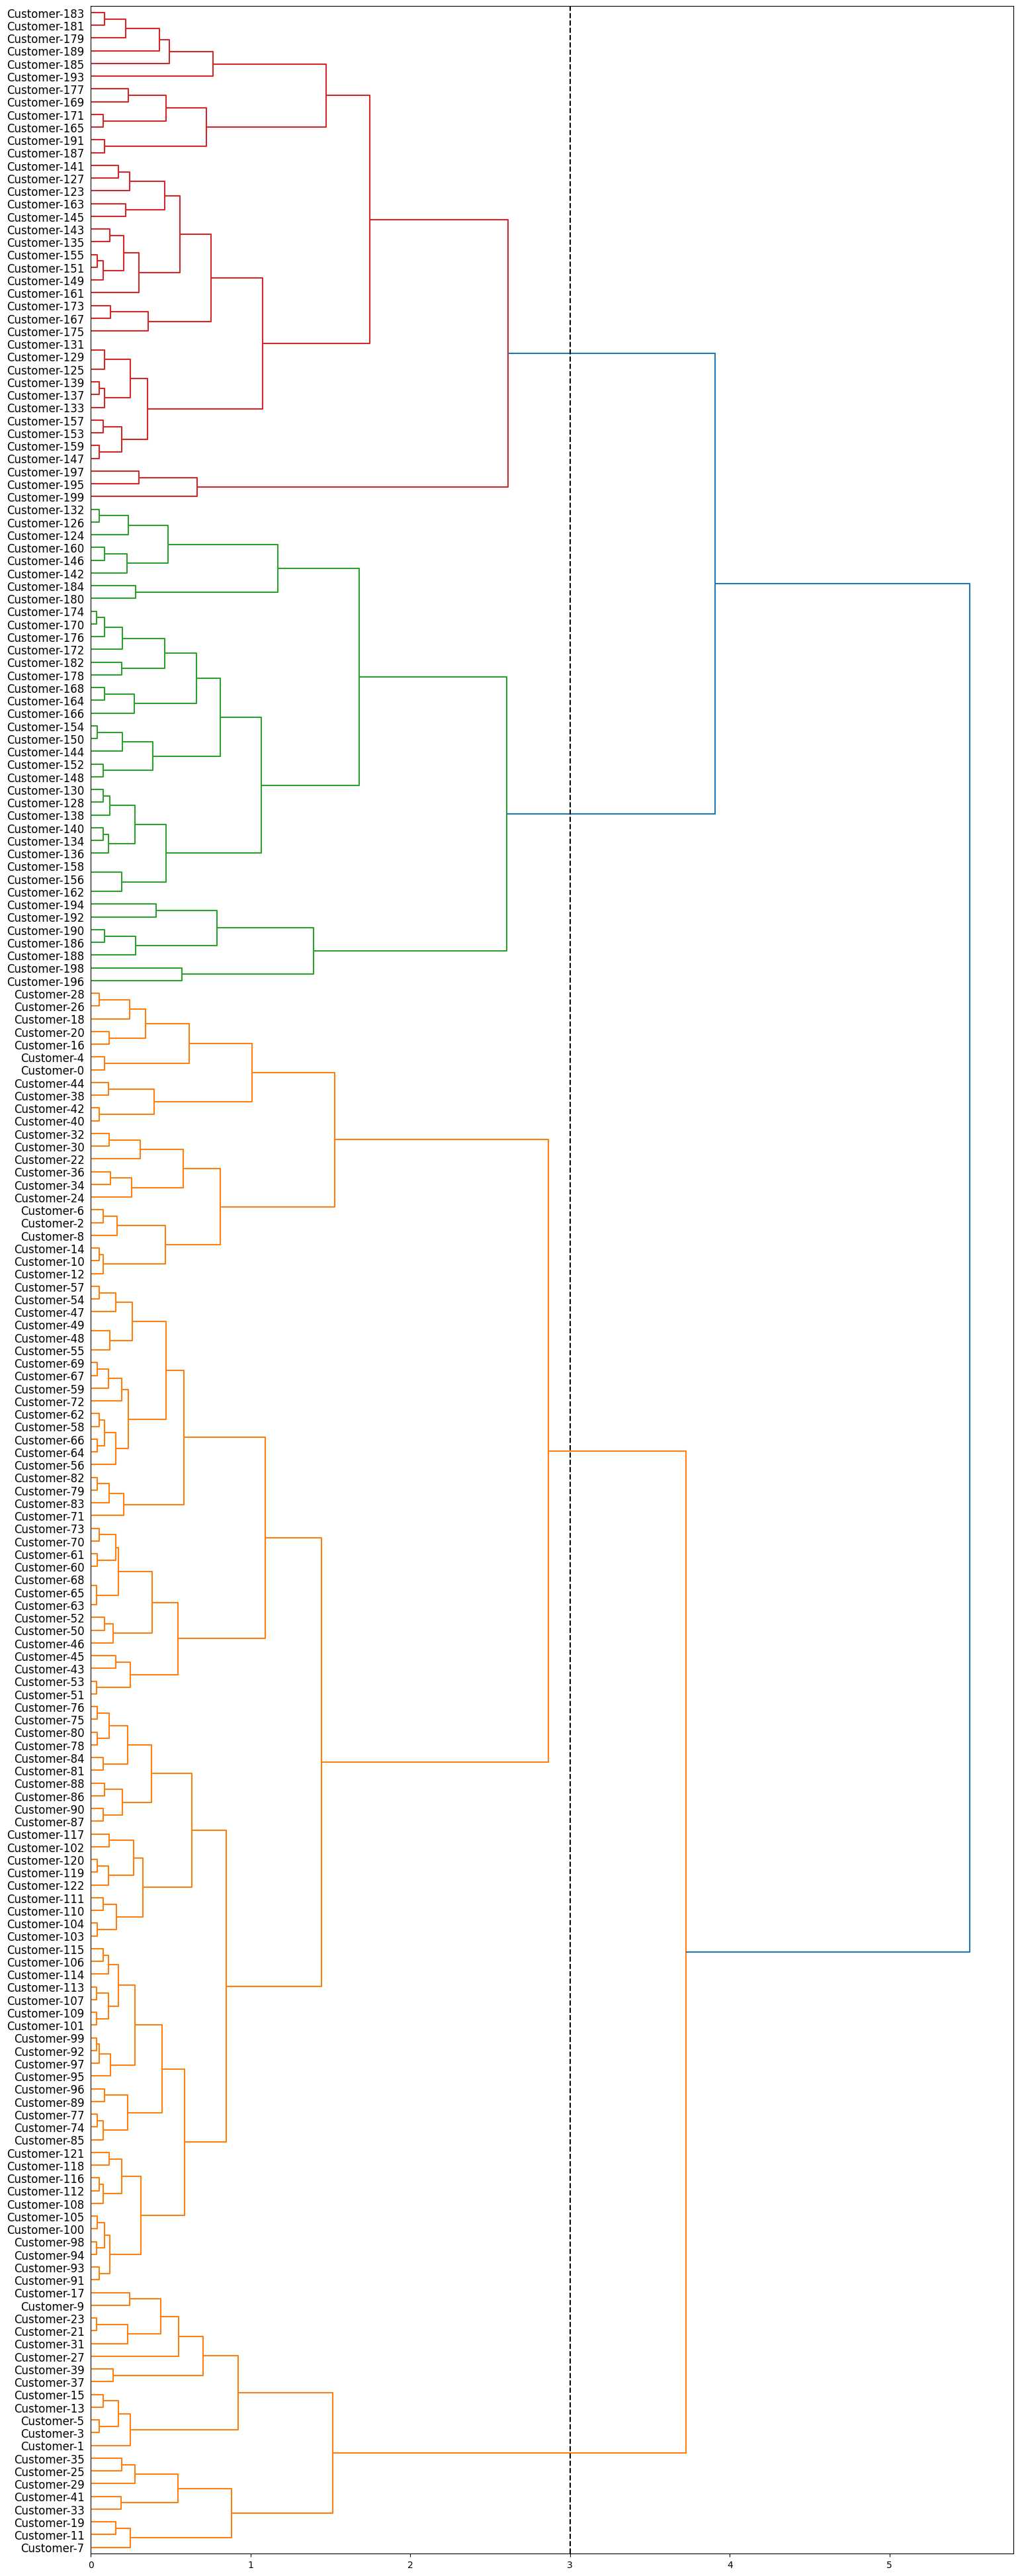

In [22]:
fig = pylab.figure(figsize=(18,50))

def llf(id):
    return f'Customer-{id}'

dendro = hierarchy.dendrogram(
    Z,
    leaf_label_func=llf,
    leaf_rotation=0,
    leaf_font_size=12,
    orientation='right'
)

plt.axvline(x=3, color='black', linestyle='--')

plt.show()

In [23]:
hier_score = silhouette_score(X, clusters)
print("Silhouette Score Hierarchical:", hier_score)

Silhouette Score Hierarchical: 0.49588122834195303


## DBSCAN

In [24]:
Clus_dataSet = df[["Annual Income (k$)", "Spending Score (1-100)"]]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

# Compute DBSCAN
db = DBSCAN(eps=0.5, min_samples=10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
df["Clus_Db"]=labels

realClusterNum=len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))

# A sample of clusters
df[["Annual Income (k$)", "Spending Score (1-100)", "Clus_Db"]].sample(5)

,Annual Income (k$),Spending Score (1-100),Clus_Db
185,99,97,2
195,120,79,-1
102,62,59,0
98,61,42,0
188,103,17,3


In [25]:
df["Clus_Db"].unique()

array([-1,  0,  1,  2,  3])

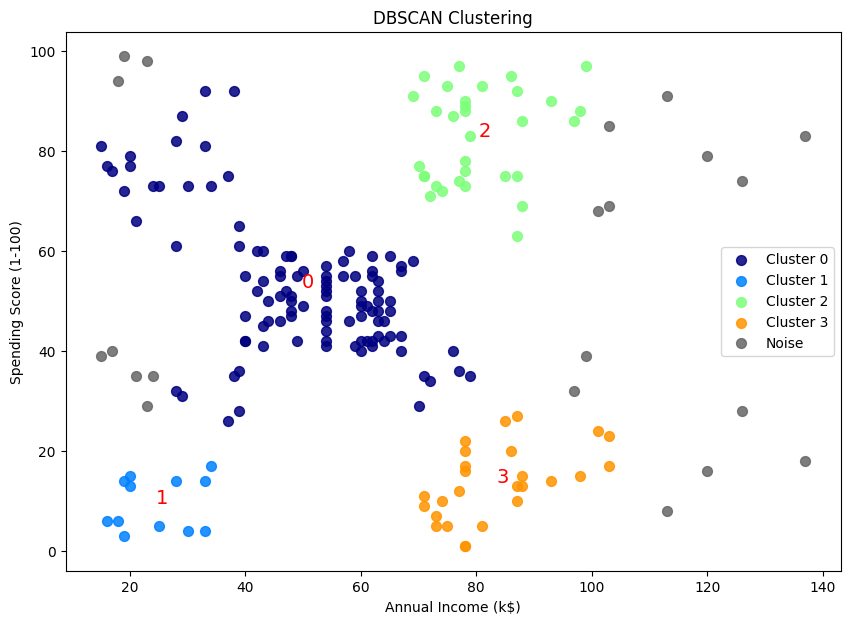

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Ambil fitur
Clus_dataSet = df[["Annual Income (k$)", "Spending Score (1-100)"]]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

# Compute DBSCAN
db = DBSCAN(eps=0.5, min_samples=10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
df["Clus_Db"] = labels

realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))

# Visualisasi
plt.figure(figsize=(10, 7))
colors = plt.cm.jet(np.linspace(0, 1, clusterNum))

for clust_number in set(labels):
    c = [0.4, 0.4, 0.4] if clust_number == -1 else colors[int(clust_number)]
    clust_set = df[df.Clus_Db == clust_number]

    plt.scatter(
        clust_set["Annual Income (k$)"],
        clust_set["Spending Score (1-100)"],
        color=c,
        s=50,
        alpha=0.85,
        label=f"Cluster {clust_number}" if clust_number != -1 else "Noise"
    )

    # Label cluster
    if clust_number != -1:
        cenx = np.mean(clust_set["Annual Income (k$)"])
        ceny = np.mean(clust_set["Spending Score (1-100)"])
        plt.text(cenx, ceny, str(clust_number), fontsize=14, color='red')

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [27]:
# Hapus noise (-1)
mask = labels != -1

# Data tanpa noise
X_no_noise = Clus_dataSet[mask]
labels_no_noise = labels[mask]

# Hitung silhouette score
score = silhouette_score(X_no_noise, labels_no_noise)

print("Silhouette Score:", score)

Silhouette Score: 0.5106676350237243


In [28]:
mask = labels != -1
for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:

    db = DBSCAN(eps=eps, min_samples=5).fit(Clus_dataSet)
    labels = db.labels_

    noise_count = sum(labels == -1)
    cluster_count = len(set(labels)) - (1 if -1 in labels else 0)

    # Hapus noise
    mask = labels != -1

    # Hitung silhouette score jika cluster > 1
    if cluster_count > 1:
        score = silhouette_score(
            Clus_dataSet[mask],
            labels[mask]
        )

        print(f"eps={eps}: clusters={cluster_count}, noise={noise_count}, silhouette_score={score:.2f}")

    else:
        print(f"eps={eps}: clusters={cluster_count}, noise={noise_count}, silhouette_score=N/A")

eps=0.3: clusters=7, noise=35, silhouette_score=0.52
eps=0.4: clusters=4, noise=15, silhouette_score=0.48
eps=0.5: clusters=2, noise=8, silhouette_score=0.39
eps=0.6: clusters=1, noise=5, silhouette_score=N/A
eps=0.7: clusters=1, noise=0, silhouette_score=N/A
